# EPL Match Outcome Prediction — Linear & Logistic Regression from Scratch
### English Premier League Dataset Analysis
Linear regression on match stats + Logistic regression for win/loss classification. Core models built from scratch using only NumPy, Pandas, Seaborn, Matplotlib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

## 1. Load & Understand the Dataset

In [2]:
df = pd.read_csv('/content/final_dataset.csv', index_col=0)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFull-Time Result distribution:")
print(df['FTR'].value_counts())
print(f"\nNulls per column:")
print(df.isnull().sum())
df.head()

Dataset shape: (6840, 39)

Columns: ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 'HM1', 'HM2', 'HM3', 'HM4', 'HM5', 'AM1', 'AM2', 'AM3', 'AM4', 'AM5', 'MW', 'HTFormPtsStr', 'ATFormPtsStr', 'HTFormPts', 'ATFormPts', 'HTWinStreak3', 'HTWinStreak5', 'HTLossStreak3', 'HTLossStreak5', 'ATWinStreak3', 'ATWinStreak5', 'ATLossStreak3', 'ATLossStreak5', 'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts']

Full-Time Result distribution:
FTR
NH    3664
H     3176
Name: count, dtype: int64

Nulls per column:
Date             0
HomeTeam         0
AwayTeam         0
FTHG             0
FTAG             0
FTR              0
HTGS             0
ATGS             0
HTGC             0
ATGC             0
HTP              0
ATP              0
HM1              0
HM2              0
HM3              0
HM4              0
HM5              0
AM1              0
AM2              0
AM3              0
AM4              0
AM5              0
MW               0
HTFormPtsStr  

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,19/08/00,Charlton,Man City,4,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,19/08/00,Chelsea,West Ham,4,2,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
2,19/08/00,Coventry,Middlesbrough,1,3,NH,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
3,19/08/00,Derby,Southampton,2,2,NH,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
4,19/08/00,Leeds,Everton,2,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0


## 2. Feature Engineering & Preprocessing

In [3]:
# Encode FTR: H=1 (home win), NH=0 (not home win — draw or away win)
df['FTR_binary'] = (df['FTR'] == 'H').astype(int)

# Form result columns (HM1-HM5, AM1-AM5) encode as W=3, D=1, L=0, M=0
form_map = {'W': 3, 'D': 1, 'L': 0, 'M': 0}
for col in ['HM1','HM2','HM3','HM4','HM5','AM1','AM2','AM3','AM4','AM5']:
    df[col + '_enc'] = df[col].map(form_map).fillna(0)

# Total goals
df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['GoalDiff']   = df['FTHG'] - df['FTAG']

# Core numeric features for our models
features = [
    'HTP', 'ATP',          # cumulative league points
    'HTFormPts', 'ATFormPts',  # recent form points
    'HTGD', 'ATGD',        # goal difference
    'DiffPts', 'DiffFormPts',  # derived differences
    'HTWinStreak3', 'HTWinStreak5',
    'ATWinStreak3', 'ATWinStreak5',
    'HTLossStreak3', 'ATLossStreak3',
    'HTGS', 'ATGS',        # goals scored season
    'HTGC', 'ATGC',        # goals conceded season
]

data = df[features + ['FTHG', 'FTAG', 'TotalGoals', 'GoalDiff', 'FTR_binary']].dropna()
print(f"Clean dataset size: {data.shape}")
print(f"Home win rate: {data['FTR_binary'].mean():.3f}")

Clean dataset size: (6840, 23)
Home win rate: 0.464


## 3. Feature Scaling (Z-score Normalisation) — Matrix Transformation
**Matrix Transformation #1:** Standardise feature matrix X using **train-set statistics only** (mu, sigma computed on X_train) to prevent data leakage. Test set is transformed with the same train-derived parameters.

In [4]:
X_raw = data[features].values   # shape (n, p) — our feature matrix
y_goals_home  = data['FTHG'].values.astype(float)
y_goals_away  = data['FTAG'].values.astype(float)
y_total_goals = data['TotalGoals'].values.astype(float)
y_goal_diff   = data['GoalDiff'].values.astype(float)
y_binary      = data['FTR_binary'].values.astype(float)

# Train/test split indices (must come before scaling to avoid leakage)
np.random.seed(42)
n = X_raw.shape[0]
idx = np.random.permutation(n)
split = int(0.8 * n)
train_idx, test_idx = idx[:split], idx[split:]

# --- Matrix Transformation #1: Z-score standardisation ---
# FIX: compute mu and sigma from TRAINING data only — prevents data leakage
mu    = X_raw[train_idx].mean(axis=0)   # mean vector (p,) — train only
sigma = X_raw[train_idx].std(axis=0)    # std vector  (p,) — train only
sigma[sigma == 0] = 1                   # avoid div-by-zero

# Apply same transform to both sets (test uses train's mu/sigma)
# Broadcasting: every row minus mu, divided by sigma — affine matrix transform
X_scaled = (X_raw - mu) / sigma

print("Feature matrix shape:", X_scaled.shape)
print("Mean after scaling train (should be ~0):", X_scaled[train_idx].mean(axis=0).round(4))
print("Std  after scaling train (should be ~1):", X_scaled[train_idx].std(axis=0).round(4))


Feature matrix shape: (6840, 18)
Mean after scaling train (should be ~0): [-0.  0.  0.  0.  0.  0.  0. -0.  0.  0. -0. -0.  0. -0. -0. -0. -0. -0.]
Std  after scaling train (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Train / Test Split
Split indices were already generated above alongside scaling. We now assign the actual train/test arrays.

In [5]:
# Split indices already computed in Cell 7 (before scaling) — assign arrays here
X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_gh_train, y_gh_test = y_goals_home[train_idx], y_goals_home[test_idx]
y_ga_train, y_ga_test = y_goals_away[train_idx], y_goals_away[test_idx]
y_tg_train, y_tg_test = y_total_goals[train_idx], y_total_goals[test_idx]
y_gd_train, y_gd_test = y_goal_diff[train_idx], y_goal_diff[test_idx]
y_b_train,  y_b_test  = y_binary[train_idx],  y_binary[test_idx]

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")


Train: 5472 samples | Test: 1368 samples


## 5. Singular Value Decomposition (SVD) for Dimensionality Analysis
**Linear Algebra Topic — SVD:** We decompose the scaled feature matrix X = U Σ Vᵀ to understand variance structure and rank. We also use the pseudo-inverse from SVD to solve the normal equations, which is numerically more stable than direct matrix inversion.

Singular values (top 10):
[156.64  150.461 117.955  82.11   80.829  71.164  70.52   53.706  53.362
  50.44 ]

Cumulative variance explained by top 5 components: 0.7550
Cumulative variance explained by top 10 components: 0.9409


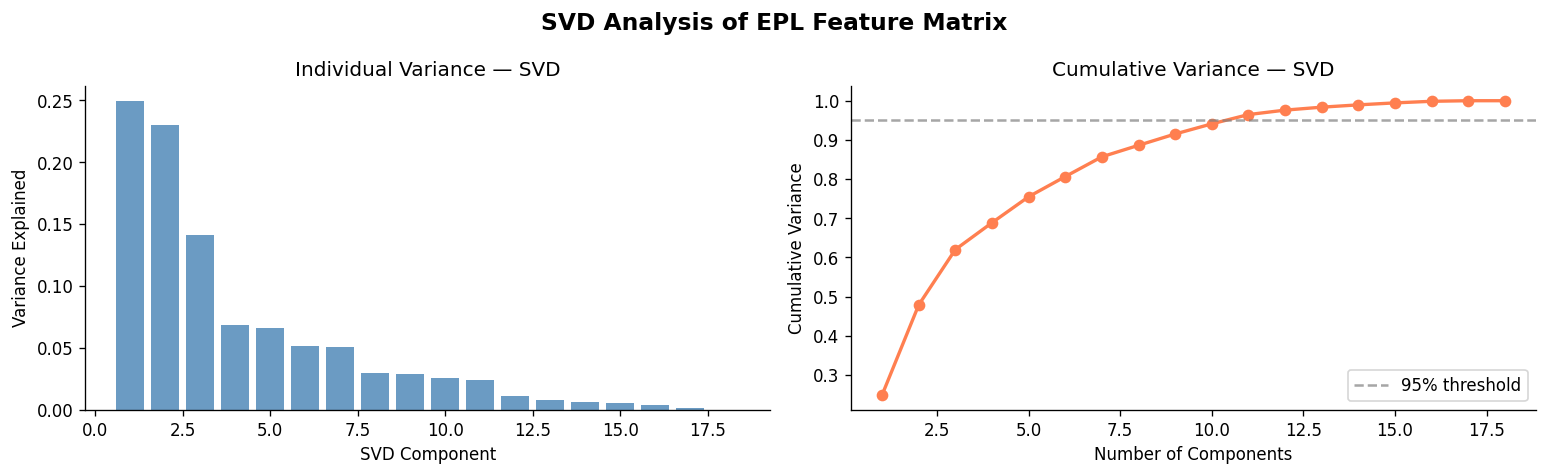


Projected feature shapes — train: (5472, 10), test: (1368, 10)


In [6]:
# SVD on training data feature matrix
U, S, Vt = np.linalg.svd(X_train, full_matrices=False)

# Singular values tell us about variance captured by each component
variance_explained = (S**2) / np.sum(S**2)
cumvar = np.cumsum(variance_explained)

print("Singular values (top 10):")
print(np.round(S[:10], 3))
print(f"\nCumulative variance explained by top 5 components: {cumvar[4]:.4f}")
print(f"Cumulative variance explained by top 10 components: {cumvar[9]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(S)+1), variance_explained, color='steelblue', alpha=0.8)
axes[0].set_xlabel('SVD Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Individual Variance — SVD')

axes[1].plot(range(1, len(S)+1), cumvar, marker='o', color='coral', linewidth=2)
axes[1].axhline(0.95, linestyle='--', color='gray', alpha=0.7, label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance — SVD')
axes[1].legend()

plt.suptitle('SVD Analysis of EPL Feature Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('svd_analysis.png', bbox_inches='tight')
plt.show()

# --- Matrix Transformation #2: project data onto top-k SVD components ---
# X_train = U S Vt, so X_train @ Vt.T = U @ diag(S) — the score matrix
k = 10  # keep top 10 components
X_train_svd = X_train @ Vt[:k].T   # project train onto right singular vectors
X_test_svd  = X_test  @ Vt[:k].T   # same transform for test
print(f"\nProjected feature shapes — train: {X_train_svd.shape}, test: {X_test_svd.shape}")

## 6. Linear Regression from Scratch — Normal Equations + Ridge Regularisation
**Matrix Inversion:** β = (XᵀX + λI)⁻¹ Xᵀy  — Ridge closed-form solution

In [7]:
def add_bias(X):
    return np.column_stack([np.ones(X.shape[0]), X])

def ridge_fit(X, y, lam=0.01):
    Xb = add_bias(X)  # (n, p+1)
    p  = Xb.shape[1]
    # Ridge normal equations: beta = (XtX + lam*I)^-1 Xt y
    # FIX: do NOT regularise the bias term — zero out position [0,0]
    reg      = lam * np.eye(p)   # (p+1, p+1)
    reg[0,0] = 0.0               # bias is unpenalised
    A    = Xb.T @ Xb + reg       # (p+1, p+1)
    b    = Xb.T @ y              # (p+1,)
    beta = np.linalg.inv(A) @ b  # closed-form inversion
    return beta

def predict_linear(X, beta):
    Xb = add_bias(X)
    return Xb @ beta

# Also implement gradient descent version for comparison
def ridge_gradient_descent(X, y, lam=0.01, lr=0.01, epochs=1000):
    Xb   = add_bias(X)
    n, p = Xb.shape
    beta = np.zeros(p)   # weight vector — satisfies vector constraint
    for _ in range(epochs):
        y_hat    = Xb @ beta
        grad     = (2/n) * Xb.T @ (y_hat - y) + 2 * lam * beta
        grad[0] -= 2 * lam * beta[0]  # don't regularise bias (already correct here)
        beta -= lr * grad
    return beta

print("Linear regression helpers defined.")
print("Ridge closed-form uses: matrix inversion (XtX + λI)⁻¹  [bias unpenalised]")
print("Gradient descent uses a weight vector and iterative updates")


Linear regression helpers defined.
Ridge closed-form uses: matrix inversion (XtX + λI)⁻¹  [bias unpenalised]
Gradient descent uses a weight vector and iterative updates


## 7. Train 4 Linear Regression Models

In [8]:
lam = 0.1

# Model 1: Predict Home Team Goals (FTHG)
beta_home_goals = ridge_fit(X_train, y_gh_train, lam=lam)

# Model 2: Predict Away Team Goals (FTAG)
beta_away_goals = ridge_fit(X_train, y_ga_train, lam=lam)

# Model 3: Predict Total Goals
beta_total_goals = ridge_fit(X_train, y_tg_train, lam=lam)

# Model 4: Predict Goal Difference — using SVD-projected features
beta_goal_diff = ridge_fit(X_train_svd, y_gd_train, lam=lam)

print("All 4 linear regression models trained.")
print(f"\nModel 1 (Home Goals) — coefficients shape: {beta_home_goals.shape}")
print(f"Model 4 (Goal Diff, SVD features) — coefficients shape: {beta_goal_diff.shape}")

All 4 linear regression models trained.

Model 1 (Home Goals) — coefficients shape: (19,)
Model 4 (Goal Diff, SVD features) — coefficients shape: (11,)


## 8. Evaluation Metrics

In [9]:
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred)**2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return float(1 - ss_res / ss_tot)

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

# Evaluate all 4 linear models
models = {
    'Home Goals (FTHG)':  (beta_home_goals,  X_test,     y_gh_test,  'linear'),
    'Away Goals (FTAG)':  (beta_away_goals,  X_test,     y_ga_test,  'linear'),
    'Total Goals':        (beta_total_goals, X_test,     y_tg_test,  'linear'),
    'Goal Difference':    (beta_goal_diff,   X_test_svd, y_gd_test,  'linear'),
}

linreg_results = {}
for name, (beta, Xte, yte, _) in models.items():
    y_pred = predict_linear(Xte, beta)
    linreg_results[name] = {
        'MSE':  round(mse(yte, y_pred),  4),
        'RMSE': round(rmse(yte, y_pred), 4),
        'MAE':  round(mae(yte, y_pred),  4),
        'R2':   round(r_squared(yte, y_pred), 4),
    }

print("=== Linear Regression Evaluation ===")
for name, metrics in linreg_results.items():
    print(f"\n{name}")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

=== Linear Regression Evaluation ===

Home Goals (FTHG)
  MSE: 1.4989
  RMSE: 1.2243
  MAE: 0.9662
  R2: 0.0822

Away Goals (FTAG)
  MSE: 1.0891
  RMSE: 1.0436
  MAE: 0.8317
  R2: 0.0593

Total Goals
  MSE: 2.6902
  RMSE: 1.6402
  MAE: 1.3069
  R2: -0.0107

Goal Difference
  MSE: 2.5007
  RMSE: 1.5814
  MAE: 1.2238
  R2: 0.1435


## 9. Visualisation — 4 Linear Regression Plots

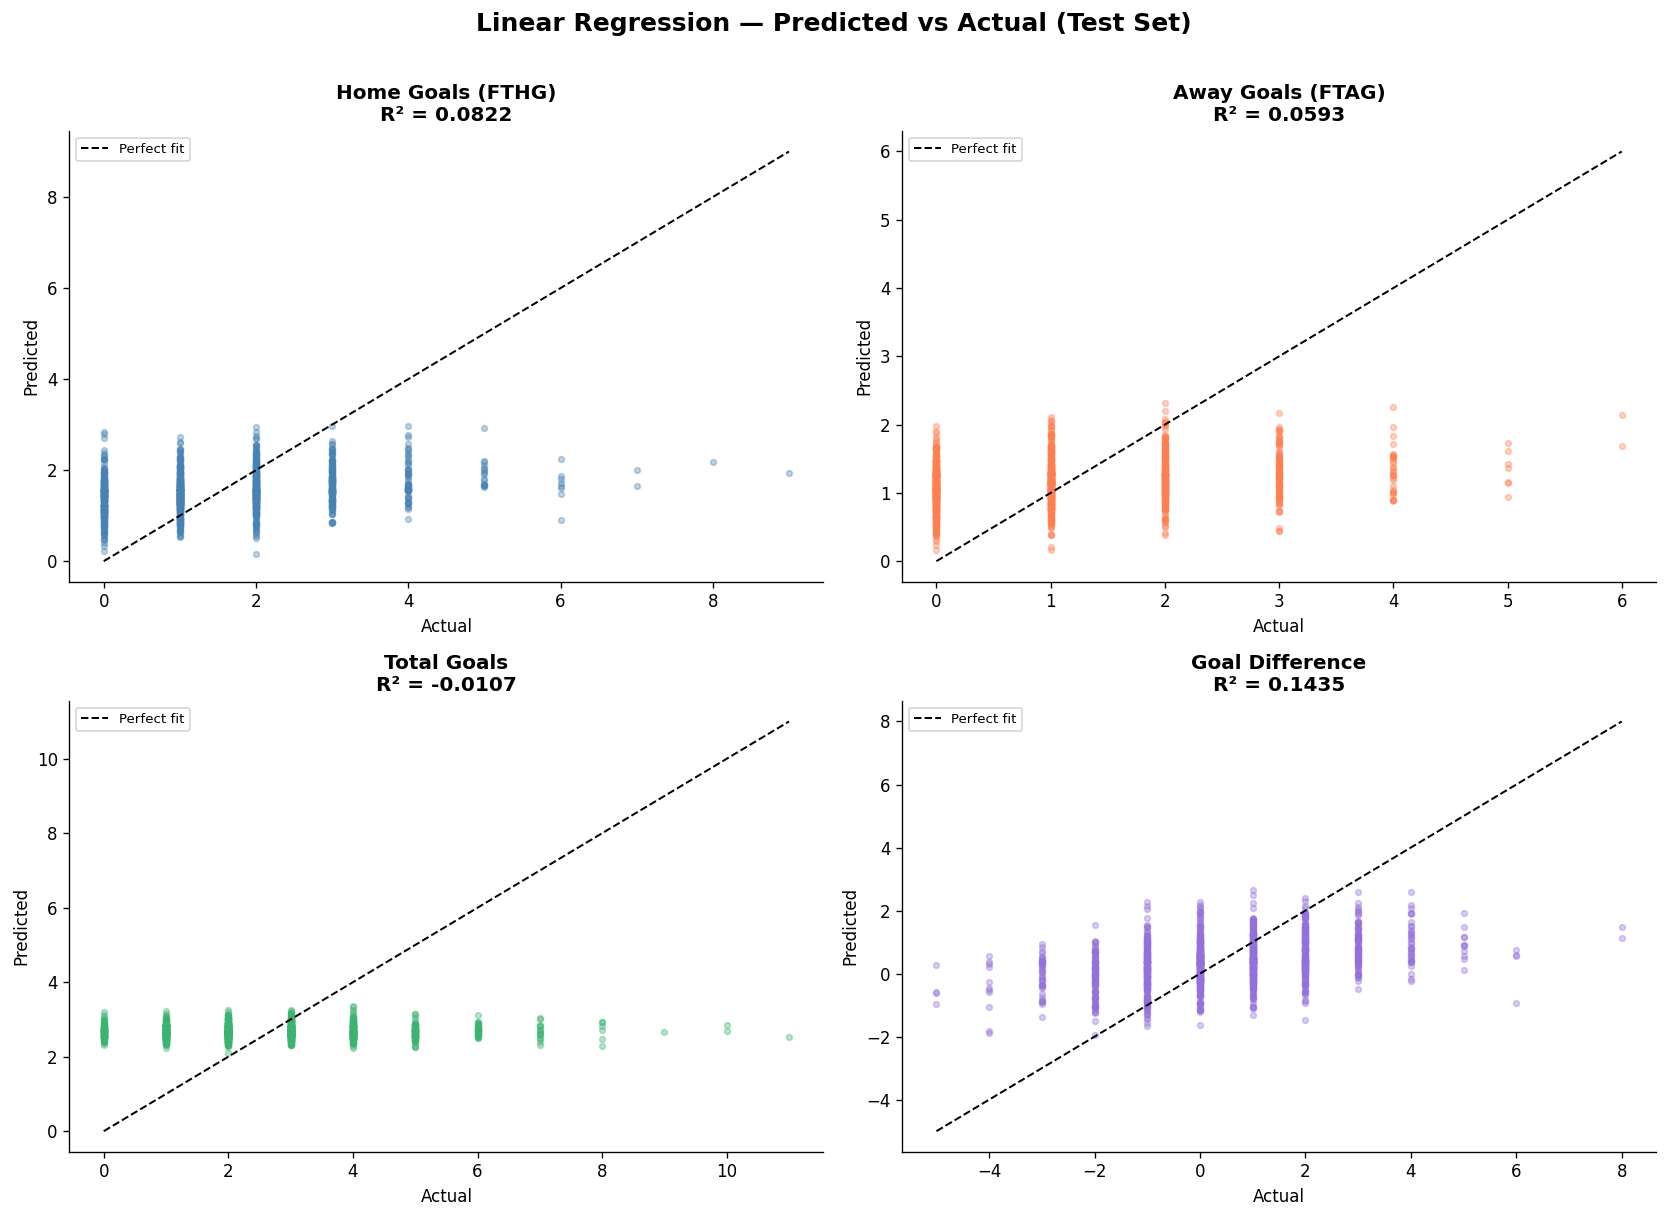

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_configs = [
    ('Home Goals (FTHG)',  beta_home_goals,  X_test,     y_gh_test,  'steelblue'),
    ('Away Goals (FTAG)',  beta_away_goals,  X_test,     y_ga_test,  'coral'),
    ('Total Goals',        beta_total_goals, X_test,     y_tg_test,  'mediumseagreen'),
    ('Goal Difference',    beta_goal_diff,   X_test_svd, y_gd_test,  'mediumpurple'),
]

for i, (name, beta, Xte, yte, color) in enumerate(plot_configs):
    y_pred = predict_linear(Xte, beta)
    r2 = r_squared(yte, y_pred)
    ax = axes[i]
    ax.scatter(yte, y_pred, alpha=0.35, s=12, color=color)
    lo = min(yte.min(), y_pred.min())
    hi = max(yte.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='Perfect fit')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Linear Regression — Predicted vs Actual (Test Set)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('linreg_pred_vs_actual.png', bbox_inches='tight')
plt.show()

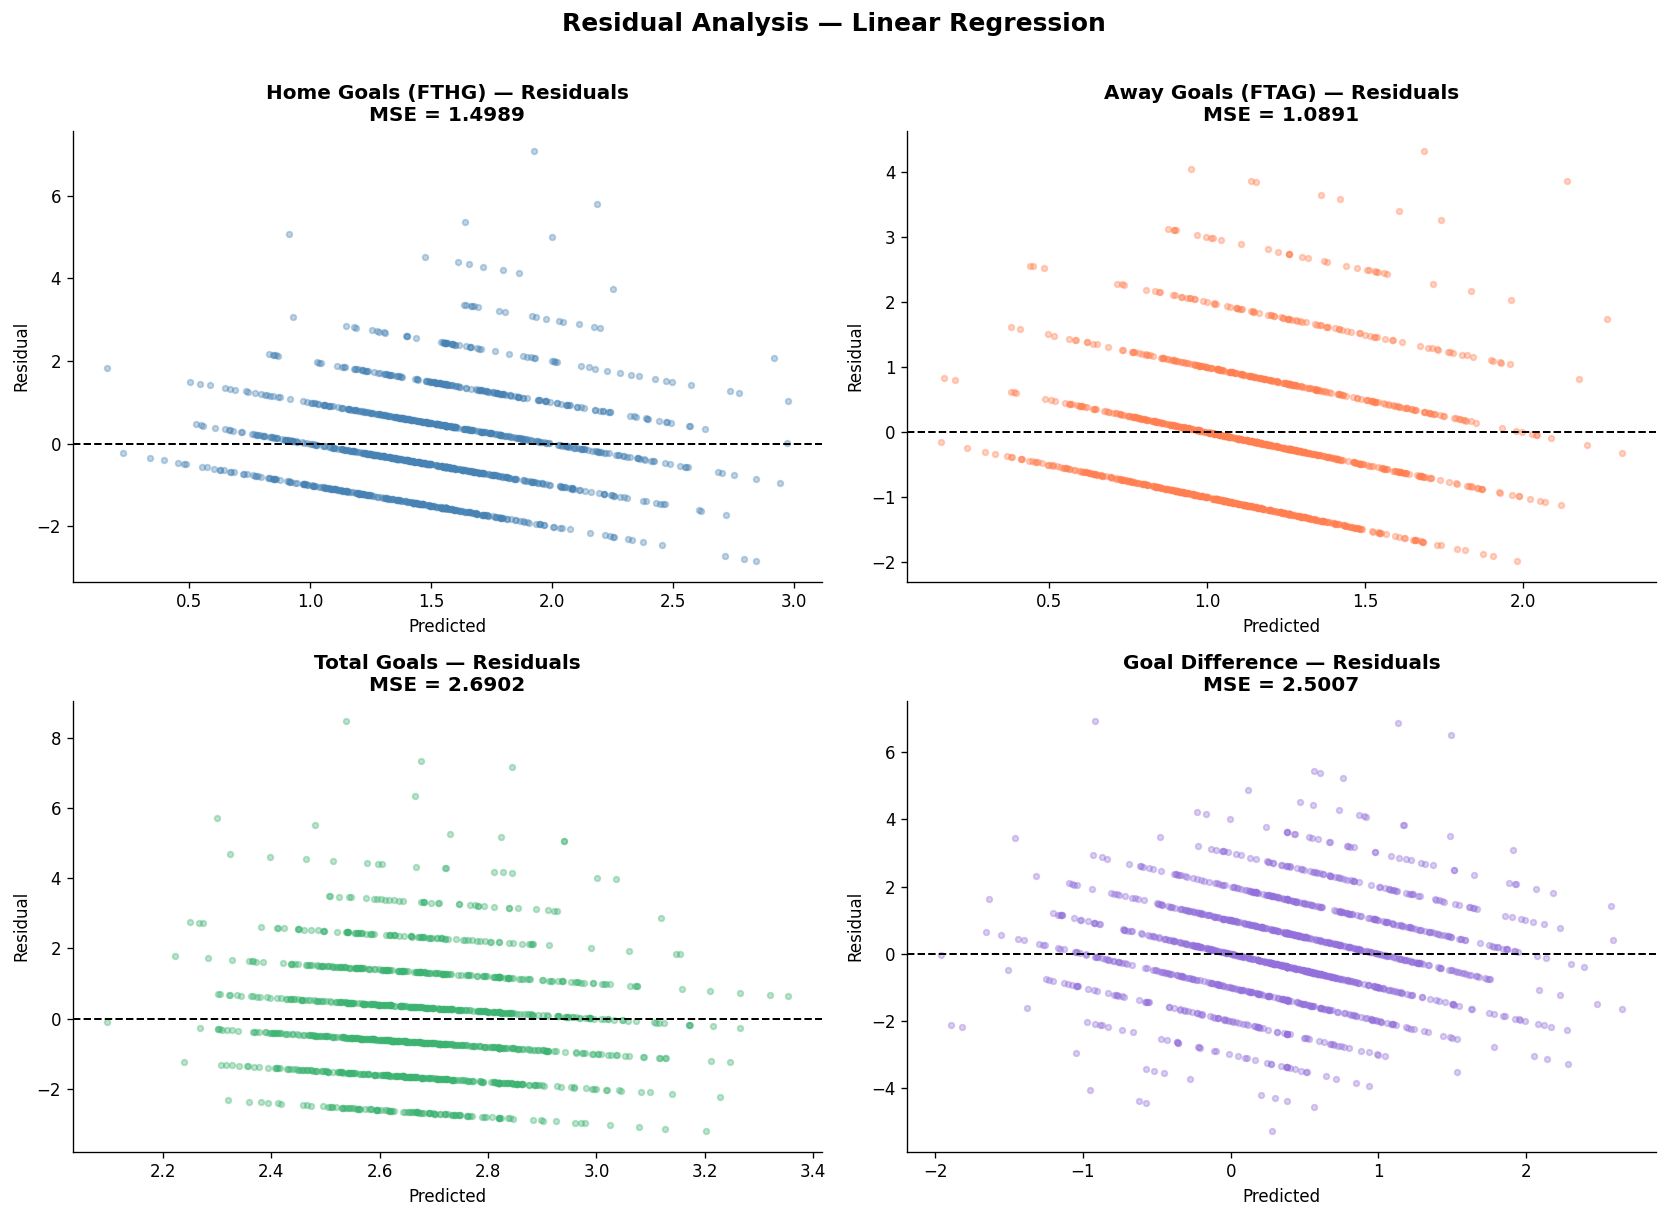

In [11]:
# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, beta, Xte, yte, color) in enumerate(plot_configs):
    y_pred = predict_linear(Xte, beta)
    residuals = yte - y_pred
    ax = axes[i]
    ax.scatter(y_pred, residuals, alpha=0.35, s=12, color=color)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    mse_v = mse(yte, y_pred)
    ax.set_title(f'{name} — Residuals\nMSE = {mse_v:.4f}', fontweight='bold')

plt.suptitle('Residual Analysis — Linear Regression', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('linreg_residuals.png', bbox_inches='tight')
plt.show()

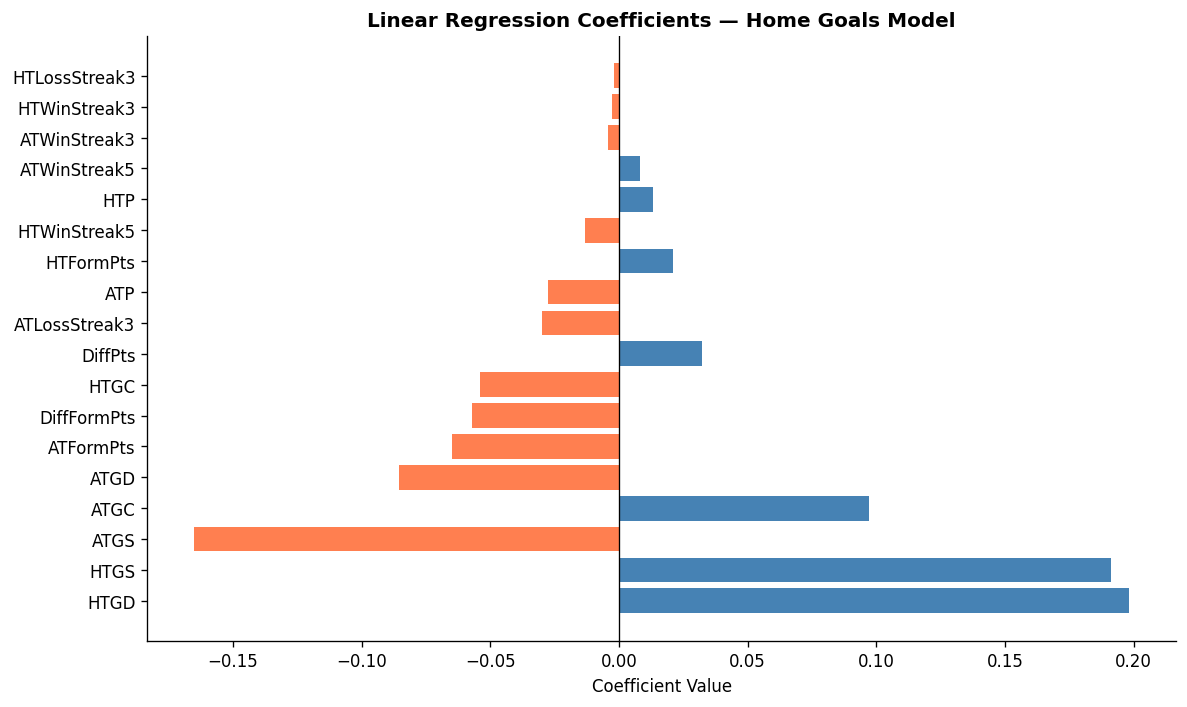

Blue = positive effect on home goals | Red = negative effect


In [12]:
# Feature importance (absolute coefficients) for Home Goals model
coef_labels = ['bias'] + features
coefs = beta_home_goals
sorted_idx = np.argsort(np.abs(coefs[1:]))[::-1]  # exclude bias

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if coefs[1:][i] > 0 else 'coral' for i in sorted_idx]
ax.barh([features[i] for i in sorted_idx], coefs[1:][sorted_idx], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title('Linear Regression Coefficients — Home Goals Model', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('linreg_coefficients.png', bbox_inches='tight')
plt.show()

print("Blue = positive effect on home goals | Red = negative effect")

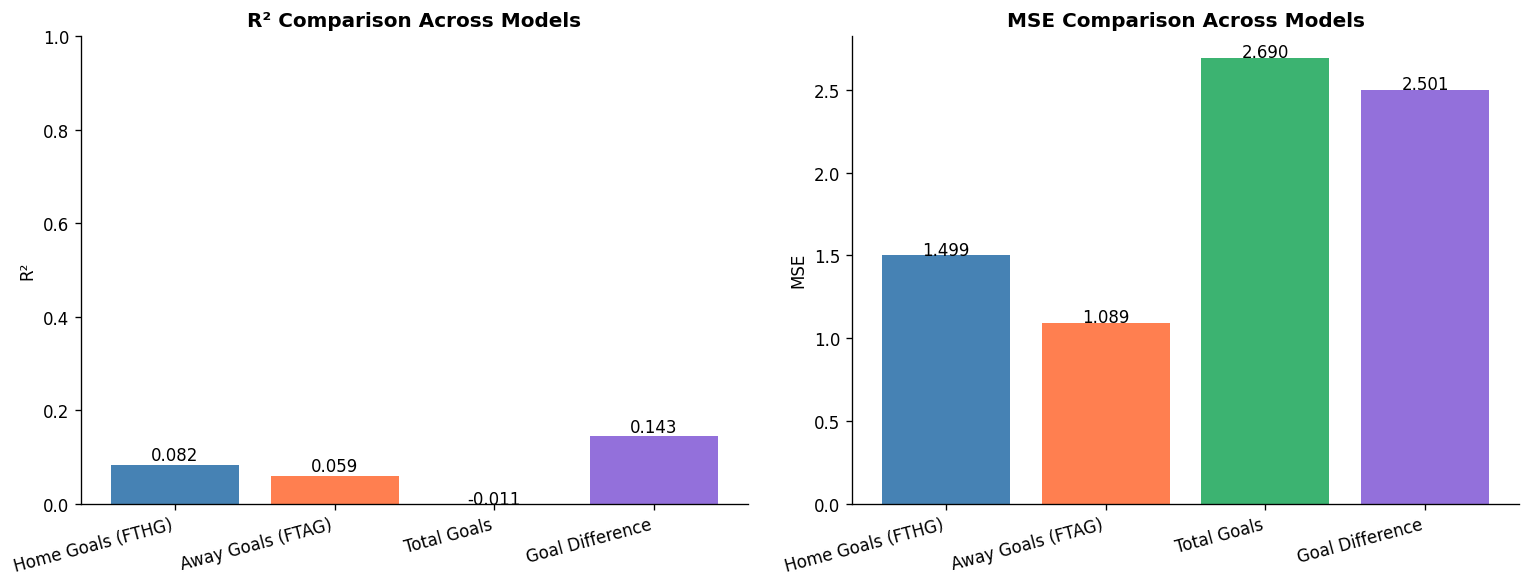

In [13]:
# Metric comparison bar chart across all 4 models
model_names = list(linreg_results.keys())
r2_vals  = [linreg_results[m]['R2']  for m in model_names]
mse_vals = [linreg_results[m]['MSE'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(model_names, r2_vals, color=['steelblue','coral','mediumseagreen','mediumpurple'])
axes[0].set_title('R² Comparison Across Models', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for j, v in enumerate(r2_vals):
    axes[0].text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(model_names, mse_vals, color=['steelblue','coral','mediumseagreen','mediumpurple'])
axes[1].set_title('MSE Comparison Across Models', fontweight='bold')
axes[1].set_ylabel('MSE')
for j, v in enumerate(mse_vals):
    axes[1].text(j, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

for ax in axes:
    ax.set_xticklabels(model_names, rotation=15, ha='right')

plt.tight_layout()
plt.savefig('linreg_comparison.png', bbox_inches='tight')
plt.show()

## 10. Logistic Regression from Scratch — Binary Cross-Entropy + L2 Regularisation
**Target:** Predict whether the home team wins (FTR == 'H')

In [14]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def logistic_fit(X, y, lam=0.01, lr=0.05, epochs=2000):
    Xb   = add_bias(X)
    n, p = Xb.shape
    beta = np.zeros(p)   # weight vector (tensor constraint)
    loss_history = []

    for epoch in range(epochs):
        z     = Xb @ beta         # linear combination — matrix-vector product
        y_hat = sigmoid(z)        # predicted probabilities (vector)

        # Binary cross-entropy loss with L2 regularisation
        eps  = 1e-15
        loss = -np.mean(y * np.log(y_hat + eps) + (1-y) * np.log(1-y_hat + eps))
        loss += (lam / (2*n)) * np.sum(beta[1:]**2)  # L2 on weights only

        grad      = (1/n) * Xb.T @ (y_hat - y)   # gradient
        grad[1:] += (lam / n) * beta[1:]          # regularisation gradient

        beta -= lr * grad
        loss_history.append(loss)

    return beta, loss_history

def predict_logistic(X, beta, threshold=0.5):
    Xb    = add_bias(X)
    proba = sigmoid(Xb @ beta)
    return proba, (proba >= threshold).astype(int)

print("Logistic regression from scratch defined.")
print("Uses: sigmoid, binary cross-entropy, L2 regularisation, gradient descent")

Logistic regression from scratch defined.
Uses: sigmoid, binary cross-entropy, L2 regularisation, gradient descent


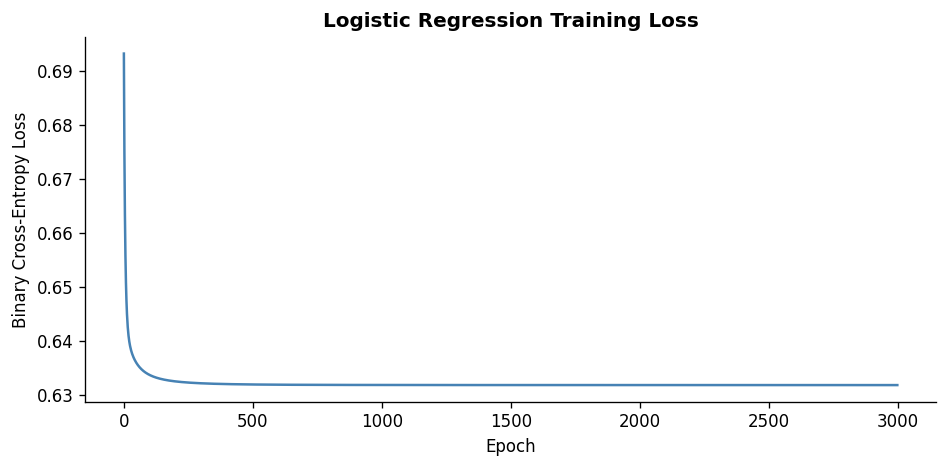

Final training loss: 0.6319


In [15]:
beta_logit, loss_hist = logistic_fit(X_train, y_b_train, lam=0.1, lr=0.1, epochs=3000)

plt.figure(figsize=(8, 4))
plt.plot(loss_hist, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Logistic Regression Training Loss', fontweight='bold')
plt.tight_layout()
plt.savefig('logit_loss.png', bbox_inches='tight')
plt.show()
print(f"Final training loss: {loss_hist[-1]:.4f}")

## 11. Logistic Regression Evaluation

In [16]:
def classification_metrics(y_true, y_pred, y_proba):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    accuracy  = (tp + tn) / len(y_true)
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    # ROC-AUC (manual trapezoidal)
    thresholds = np.linspace(0, 1, 200)
    tprs, fprs = [], []
    for t in thresholds:
        pred_t = (y_proba >= t).astype(int)
        tpr = np.sum((pred_t == 1) & (y_true == 1)) / (np.sum(y_true == 1) + 1e-9)
        fpr = np.sum((pred_t == 1) & (y_true == 0)) / (np.sum(y_true == 0) + 1e-9)
        tprs.append(tpr)
        fprs.append(fpr)
    auc = float(np.trapz(tprs[::-1], fprs[::-1]))

    return {
        'accuracy':  round(float(accuracy),  4),
        'precision': round(float(precision), 4),
        'recall':    round(float(recall),    4),
        'f1':        round(float(f1),        4),
        'auc_roc':   round(abs(auc),         4),
        'conf_matrix': [[int(tn), int(fp)], [int(fn), int(tp)]]
    }, fprs, tprs

proba_test, pred_test = predict_logistic(X_test, beta_logit)
proba_train, pred_train = predict_logistic(X_train, beta_logit)

logit_metrics, fprs, tprs = classification_metrics(y_b_test, pred_test, proba_test)
logit_train_metrics, _, _ = classification_metrics(y_b_train, pred_train, proba_train)

print("=== Logistic Regression Evaluation ===")
print(f"\nTest Set:")
for k, v in logit_metrics.items():
    if k != 'conf_matrix':
        print(f"  {k}: {v}")
print(f"  Confusion Matrix: {logit_metrics['conf_matrix']}")
print(f"\nTrain Set Accuracy: {logit_train_metrics['accuracy']}")

=== Logistic Regression Evaluation ===

Test Set:
  accuracy: 0.6308
  precision: 0.6227
  recall: 0.5259
  f1: 0.5702
  auc_roc: 0.679
  Confusion Matrix: [[528, 203], [302, 335]]

Train Set Accuracy: 0.6405


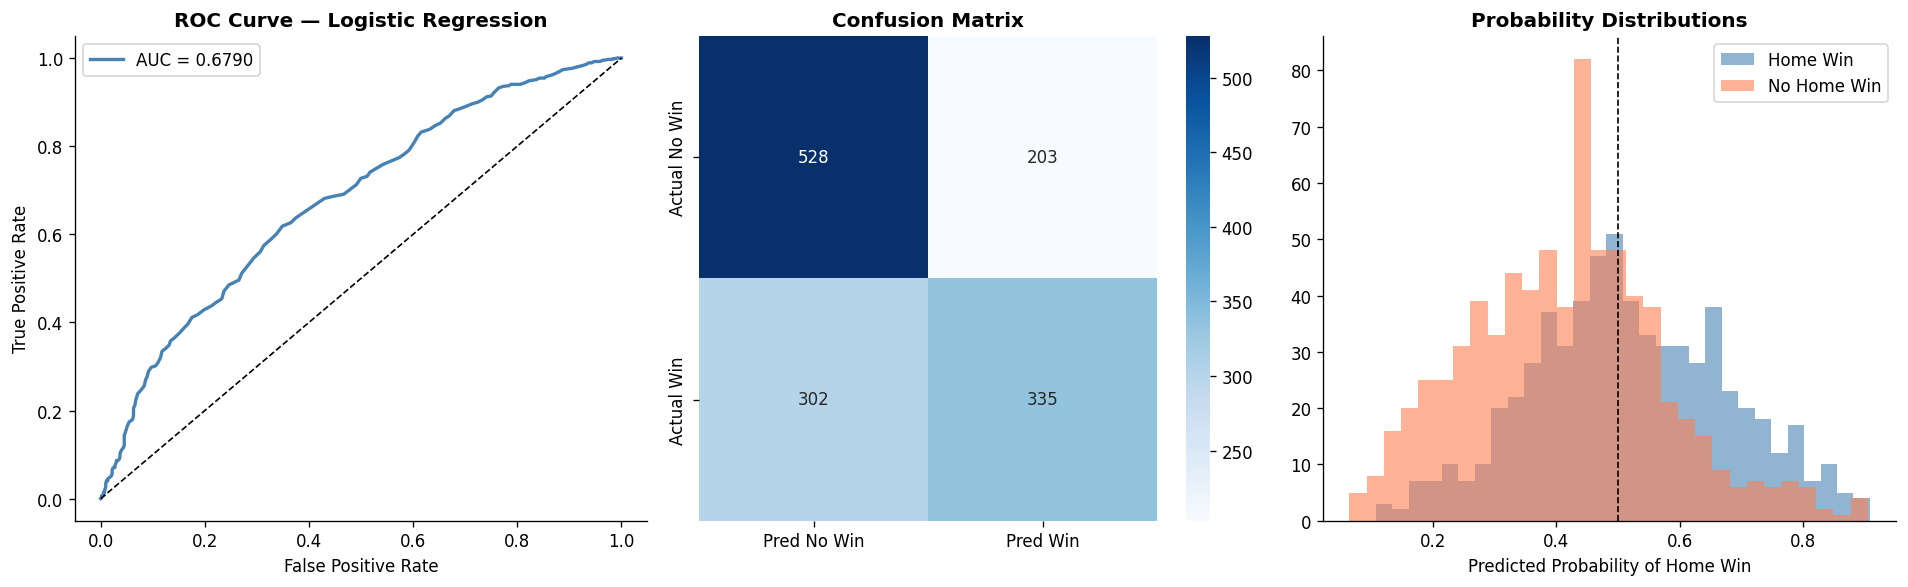

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve
axes[0].plot(fprs[::-1], tprs[::-1], color='steelblue', linewidth=2,
             label=f"AUC = {logit_metrics['auc_roc']:.4f}")
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Logistic Regression', fontweight='bold')
axes[0].legend()

# Confusion matrix heatmap
cm = np.array(logit_metrics['conf_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred No Win','Pred Win'],
            yticklabels=['Actual No Win','Actual Win'])
axes[1].set_title('Confusion Matrix', fontweight='bold')

# Predicted probability distribution
axes[2].hist(proba_test[y_b_test == 1], bins=30, alpha=0.6, color='steelblue', label='Home Win')
axes[2].hist(proba_test[y_b_test == 0], bins=30, alpha=0.6, color='coral', label='No Home Win')
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Predicted Probability of Home Win')
axes[2].set_title('Probability Distributions', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('logit_evaluation.png', bbox_inches='tight')
plt.show()

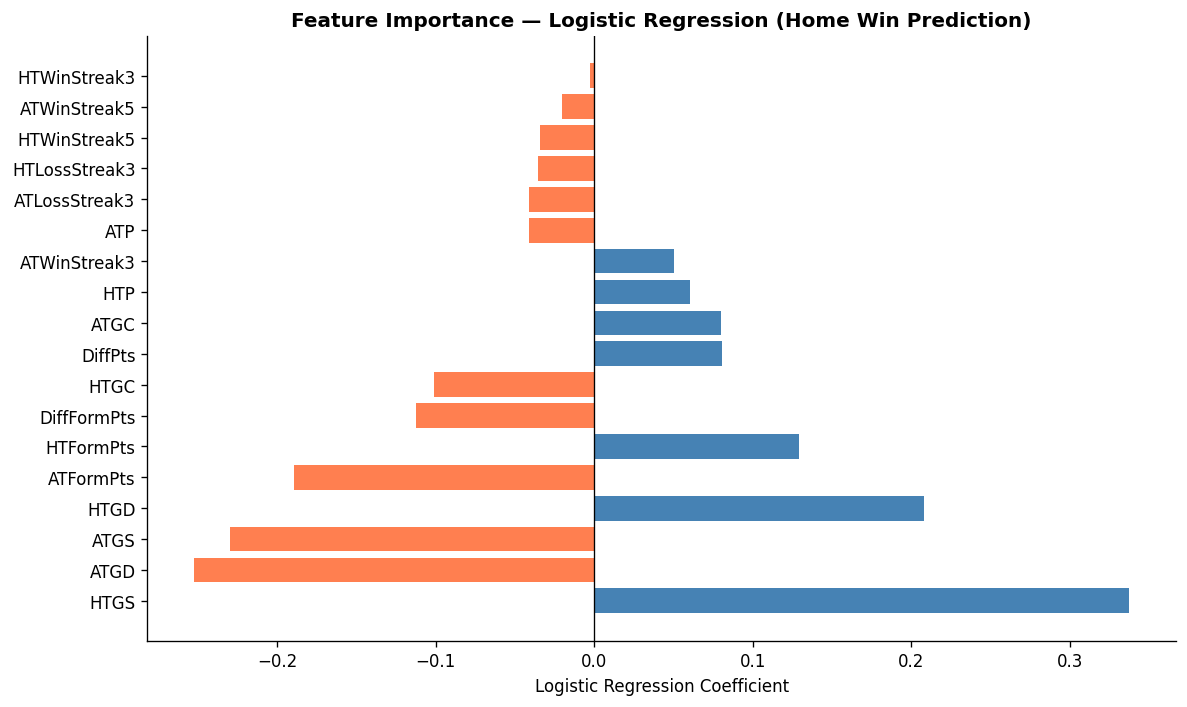

In [18]:
# Logistic regression coefficient importance
coef_labels_logit = features
logit_coefs = beta_logit[1:]  # exclude bias
sorted_idx_logit = np.argsort(np.abs(logit_coefs))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if logit_coefs[i] > 0 else 'coral' for i in sorted_idx_logit]
ax.barh([features[i] for i in sorted_idx_logit], logit_coefs[sorted_idx_logit], color=colors)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Feature Importance — Logistic Regression (Home Win Prediction)', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('logit_coefs.png', bbox_inches='tight')
plt.show()

## 12. Matrix Transformation Summary

In [19]:
matrix_transforms = {
    'Transform 1 — Feature Standardisation': {
        'description': 'X_scaled = (X_raw - mu) / sigma',
        'type': 'Affine matrix transform (column-wise)',
        'input_shape': list(X_raw.shape),
        'output_shape': list(X_scaled.shape),
    },
    'Transform 2 — SVD Projection': {
        'description': 'X_proj = X_scaled @ Vt[:k].T  — project onto top-k right singular vectors',
        'type': 'Matrix multiplication (dimensionality reduction)',
        'input_shape': list(X_train.shape),
        'output_shape': list(X_train_svd.shape),
        'note': 'X_train = U Σ Vᵀ decomposed; Vt rows are orthonormal basis of feature space',
    },
    'Transform 3 — Ridge Normal Equations': {
        'description': 'beta = (XᵀX + λI)⁻¹ Xᵀy',
        'type': 'Matrix inversion of (p+1)×(p+1) system',
        'note': 'λ regularisation shifts eigenvalues, ensuring invertibility',
    },
    'Vectors/Tensors used': {
        'weight vector beta': '1D numpy array of shape (p+1,) for all regression models',
        'gradient vector': '1D array (p+1,) updated each epoch in logistic regression',
        'singular values S': '1D array (min(n,p),) from SVD — represents scale of each component',
    }
}

with open('matrix_transforms.txt', 'w') as f:
    f.write("=== Matrix Transformations Used in This Notebook ===\n\n")
    for title, details in matrix_transforms.items():
        f.write(f"--- {title} ---\n")
        for k, v in details.items():
            f.write(f"  {k}: {v}\n")
        f.write("\n")

print("matrix_transforms.txt written.")
for title, details in matrix_transforms.items():
    print(f"\n{title}")
    for k, v in details.items():
        print(f"  {k}: {v}")

matrix_transforms.txt written.

Transform 1 — Feature Standardisation
  description: X_scaled = (X_raw - mu) / sigma
  type: Affine matrix transform (column-wise)
  input_shape: [6840, 18]
  output_shape: [6840, 18]

Transform 2 — SVD Projection
  description: X_proj = X_scaled @ Vt[:k].T  — project onto top-k right singular vectors
  type: Matrix multiplication (dimensionality reduction)
  input_shape: [5472, 18]
  output_shape: [5472, 10]
  note: X_train = U Σ Vᵀ decomposed; Vt rows are orthonormal basis of feature space

Transform 3 — Ridge Normal Equations
  description: beta = (XᵀX + λI)⁻¹ Xᵀy
  type: Matrix inversion of (p+1)×(p+1) system
  note: λ regularisation shifts eigenvalues, ensuring invertibility

Vectors/Tensors used
  weight vector beta: 1D numpy array of shape (p+1,) for all regression models
  gradient vector: 1D array (p+1,) updated each epoch in logistic regression
  singular values S: 1D array (min(n,p),) from SVD — represents scale of each component


## 13. Additional EDA Visualisations

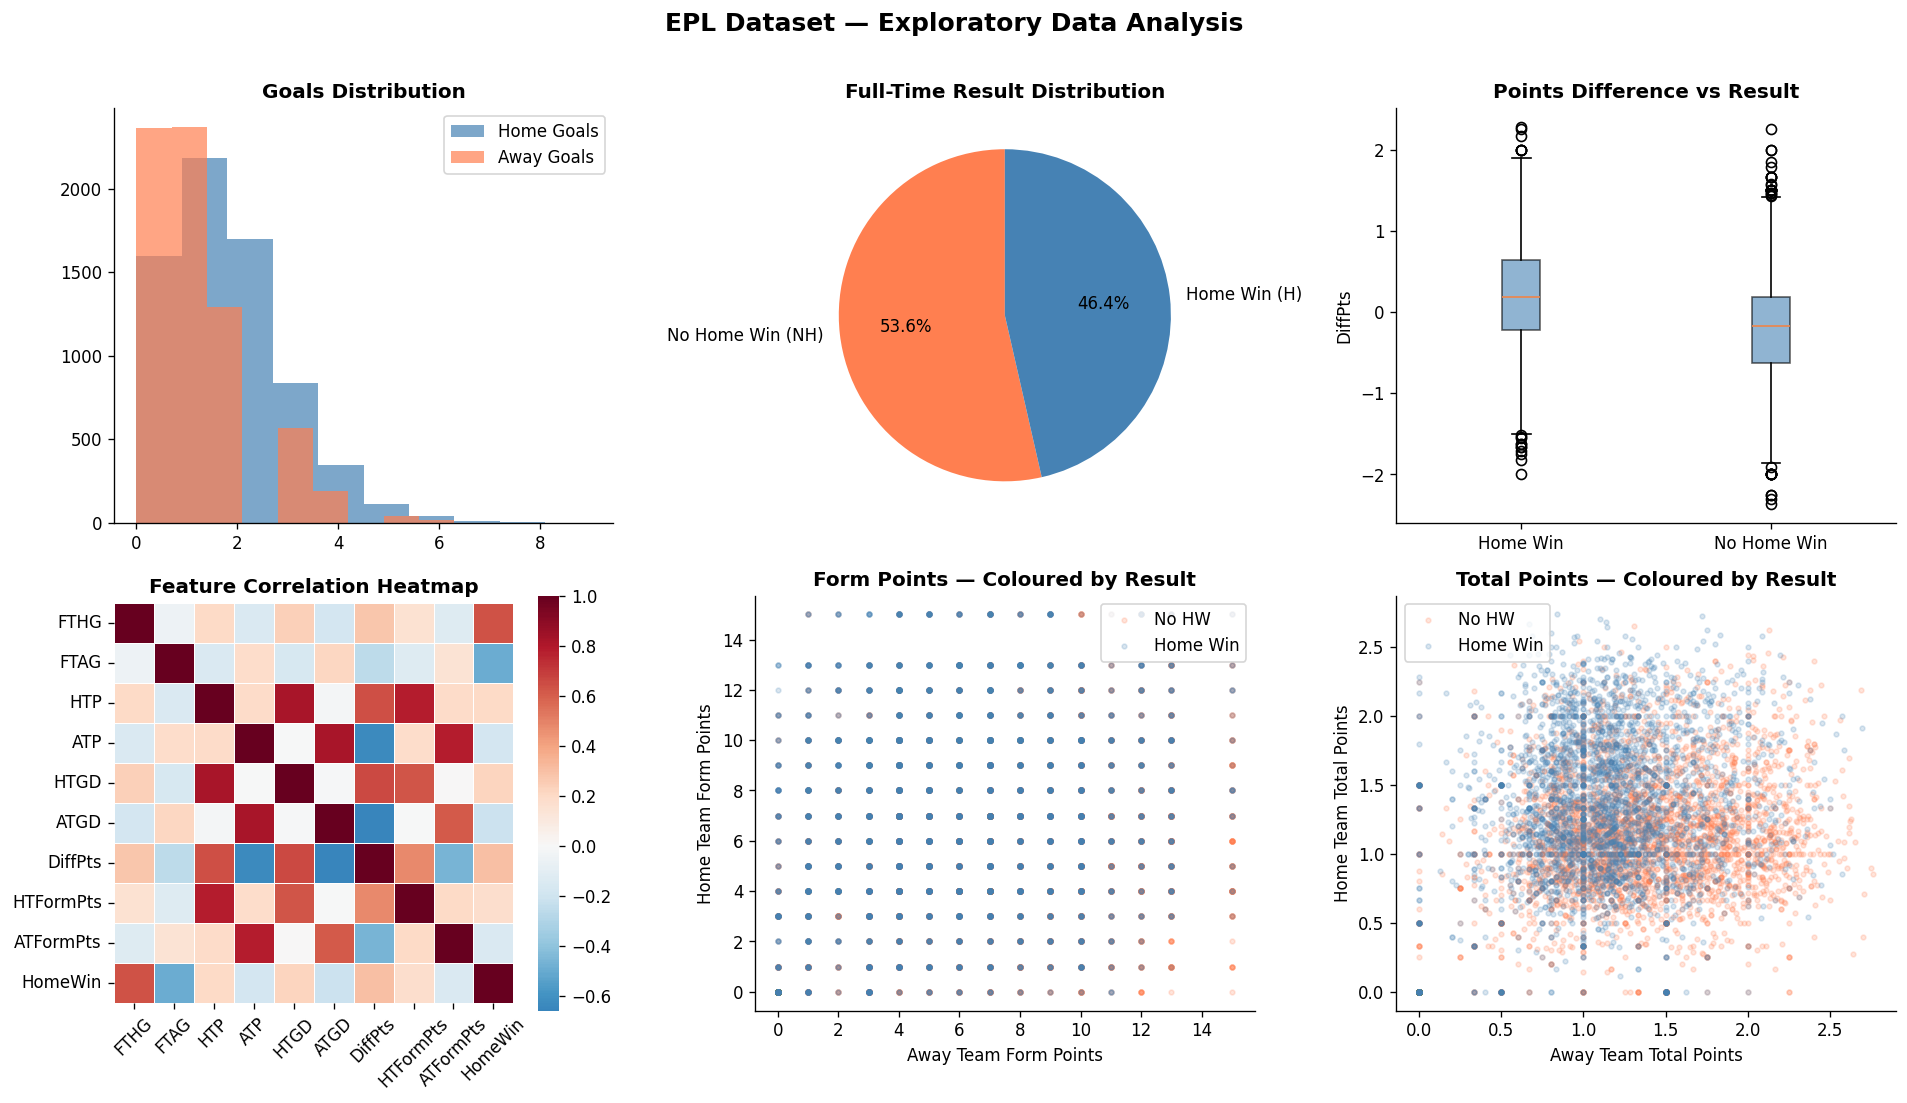

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Goal distributions
axes[0,0].hist(df['FTHG'], bins=10, color='steelblue', alpha=0.7, label='Home Goals')
axes[0,0].hist(df['FTAG'], bins=10, color='coral', alpha=0.7, label='Away Goals')
axes[0,0].set_title('Goals Distribution', fontweight='bold')
axes[0,0].legend()

# FTR pie
ftr_counts = df['FTR'].value_counts()
axes[0,1].pie(ftr_counts, labels=['No Home Win (NH)', 'Home Win (H)'],
              autopct='%1.1f%%', colors=['coral', 'steelblue'], startangle=90)
axes[0,1].set_title('Full-Time Result Distribution', fontweight='bold')

# DiffPts vs FTR_binary
axes[0,2].boxplot(
    [df.loc[df['FTR_binary']==1,'DiffPts'].dropna().values,
     df.loc[df['FTR_binary']==0,'DiffPts'].dropna().values],
    labels=['Home Win', 'No Home Win'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[0,2].set_title('Points Difference vs Result', fontweight='bold')
axes[0,2].set_ylabel('DiffPts')

# Correlation heatmap of key features
corr_cols = ['FTHG','FTAG','HTP','ATP','HTGD','ATGD','DiffPts','HTFormPts','ATFormPts','FTR_binary']
corr_df = data[corr_cols].rename(columns={'FTR_binary':'HomeWin'})
corr_mat = corr_df.corr()
sns.heatmap(corr_mat, ax=axes[1,0], cmap='RdBu_r', center=0, annot=False,
            linewidths=0.3, square=True)
axes[1,0].set_title('Feature Correlation Heatmap', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

# HTFormPts vs ATFormPts scatter coloured by result
hw  = data[data['FTR_binary']==1]
nhw = data[data['FTR_binary']==0]
axes[1,1].scatter(nhw['ATFormPts'], nhw['HTFormPts'], alpha=0.2, s=8, color='coral', label='No HW')
axes[1,1].scatter(hw['ATFormPts'],  hw['HTFormPts'],  alpha=0.2, s=8, color='steelblue', label='Home Win')
axes[1,1].set_xlabel('Away Team Form Points')
axes[1,1].set_ylabel('Home Team Form Points')
axes[1,1].set_title('Form Points — Coloured by Result', fontweight='bold')
axes[1,1].legend()

# HTP vs ATP
axes[1,2].scatter(nhw['ATP'], nhw['HTP'], alpha=0.2, s=8, color='coral', label='No HW')
axes[1,2].scatter(hw['ATP'],  hw['HTP'],  alpha=0.2, s=8, color='steelblue', label='Home Win')
axes[1,2].set_xlabel('Away Team Total Points')
axes[1,2].set_ylabel('Home Team Total Points')
axes[1,2].set_title('Total Points — Coloured by Result', fontweight='bold')
axes[1,2].legend()

plt.suptitle('EPL Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda.png', bbox_inches='tight')
plt.show()

## 14. Conclusion & Results Summary

In [21]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print("\n--- Linear Regression (Ridge, λ=0.1) ---")
for name, metrics in linreg_results.items():
    print(f"  {name}: MSE={metrics['MSE']}, RMSE={metrics['RMSE']}, R²={metrics['R2']}")

print(f"\n--- Logistic Regression (L2, λ=0.1, 3000 epochs) ---")
print(f"  Accuracy:  {logit_metrics['accuracy']}")
print(f"  Precision: {logit_metrics['precision']}")
print(f"  Recall:    {logit_metrics['recall']}")
print(f"  F1 Score:  {logit_metrics['f1']}")
print(f"  AUC-ROC:   {logit_metrics['auc_roc']}")

print("\n--- Linear Algebra: SVD ---")
print(f"  Variance captured by top 5 SVD components:  {cumvar[4]:.4f}")
print(f"  Variance captured by top 10 SVD components: {cumvar[9]:.4f}")

print("\n--- Comparisons ---")
best_linreg = max(linreg_results.items(), key=lambda x: x[1]['R2'])
print(f"  Best linear model by R²: {best_linreg[0]} (R²={best_linreg[1]['R2']})")
print(f"  Logistic regression can classify home wins with AUC={logit_metrics['auc_roc']}")
print(f"  Home team advantage is real — home win rate: {y_binary.mean():.3f} vs random 0.5")

FINAL RESULTS SUMMARY

--- Linear Regression (Ridge, λ=0.1) ---
  Home Goals (FTHG): MSE=1.4989, RMSE=1.2243, R²=0.0822
  Away Goals (FTAG): MSE=1.0891, RMSE=1.0436, R²=0.0593
  Total Goals: MSE=2.6902, RMSE=1.6402, R²=-0.0107
  Goal Difference: MSE=2.5007, RMSE=1.5814, R²=0.1435

--- Logistic Regression (L2, λ=0.1, 3000 epochs) ---
  Accuracy:  0.6308
  Precision: 0.6227
  Recall:    0.5259
  F1 Score:  0.5702
  AUC-ROC:   0.679

--- Linear Algebra: SVD ---
  Variance captured by top 5 SVD components:  0.7550
  Variance captured by top 10 SVD components: 0.9409

--- Comparisons ---
  Best linear model by R²: Goal Difference (R²=0.1435)
  Logistic regression can classify home wins with AUC=0.679
  Home team advantage is real — home win rate: 0.464 vs random 0.5


## 15. Save Results to JSON

In [22]:
results_json = {
    'model': 'Linear + Logistic Regression (from scratch)',
    'dataset': 'EPL 2000-2019',
    'n_samples': int(data.shape[0]),
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'regularisation': 'Ridge L2 lambda=0.1',
    'linear_regression': linreg_results,
    'logistic_regression': {
        'task': 'Binary classification — Home Win prediction',
        'accuracy':  logit_metrics['accuracy'],
        'precision': logit_metrics['precision'],
        'recall':    logit_metrics['recall'],
        'f1':        logit_metrics['f1'],
        'auc_roc':   logit_metrics['auc_roc'],
        'conf_matrix': logit_metrics['conf_matrix'],
        # For CNN comparison — use these metrics
        'comparable_metrics': {
            'accuracy':  logit_metrics['accuracy'],
            'f1':        logit_metrics['f1'],
            'auc_roc':   logit_metrics['auc_roc'],
            'precision': logit_metrics['precision'],
            'recall':    logit_metrics['recall'],
        }
    },
    'svd_analysis': {
        'n_components': int(len(S)),
        'variance_top5':  round(float(cumvar[4]), 4),
        'variance_top10': round(float(cumvar[9]), 4),
    }
}

with open('regression_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print("Results saved to regression_results.json")
print(json.dumps(results_json, indent=2))

Results saved to regression_results.json
{
  "model": "Linear + Logistic Regression (from scratch)",
  "dataset": "EPL 2000-2019",
  "n_samples": 6840,
  "train_size": 5472,
  "test_size": 1368,
  "regularisation": "Ridge L2 lambda=0.1",
  "linear_regression": {
    "Home Goals (FTHG)": {
      "MSE": 1.4989,
      "RMSE": 1.2243,
      "MAE": 0.9662,
      "R2": 0.0822
    },
    "Away Goals (FTAG)": {
      "MSE": 1.0891,
      "RMSE": 1.0436,
      "MAE": 0.8317,
      "R2": 0.0593
    },
    "Total Goals": {
      "MSE": 2.6902,
      "RMSE": 1.6402,
      "MAE": 1.3069,
      "R2": -0.0107
    },
    "Goal Difference": {
      "MSE": 2.5007,
      "RMSE": 1.5814,
      "MAE": 1.2238,
      "R2": 0.1435
    }
  },
  "logistic_regression": {
    "task": "Binary classification \u2014 Home Win prediction",
    "accuracy": 0.6308,
    "precision": 0.6227,
    "recall": 0.5259,
    "f1": 0.5702,
    "auc_roc": 0.679,
    "conf_matrix": [
      [
        528,
        203
      ],
      [